In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, string
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from gensim.models import Word2Vec
import gensim.downloader as api

np.random.seed(42)
pd.set_option('display.max_colwidth', 100)

print("Libraries imported successfully!")

# Add project root to sys.path
root_path = Path.cwd().parent 
if str(root_path) not in sys.path:
    sys.path.insert(0, str(root_path))

#Import
from pipelines.data_pipeline import load_raw_data, save_processed_data
from pipelines.data_cleaning_request_pipeline import  complaints_engineer_features, clean_selected_columns, get_top_words_by_category, get_sequence_stats



Libraries imported successfully!


In [2]:
#Load the City Traffic Accident Database
df_= load_raw_data("urbanpulse_311_complaints.csv")
df_311 = df_.copy()
missing_count = df_311.isnull().sum()

print(missing_count)

unique_key                    0
created_date                  0
closed_date               50080
agency                        0
agency_name                   0
complaint_type                0
descriptor                 3675
resolution_description        0
borough                       0
open_data_channel_type        0
status                        0
dtype: int64


In [3]:
df_311.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 434722 entries, 0 to 434721
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   unique_key              434722 non-null  int64 
 1   created_date            434722 non-null  object
 2   closed_date             384642 non-null  object
 3   agency                  434722 non-null  object
 4   agency_name             434722 non-null  object
 5   complaint_type          434722 non-null  object
 6   descriptor              431047 non-null  object
 7   resolution_description  434722 non-null  object
 8   borough                 434722 non-null  object
 9   open_data_channel_type  434722 non-null  object
 10  status                  434722 non-null  object
dtypes: int64(1), object(10)
memory usage: 36.5+ MB


In [4]:
df_311.head()



,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,resolution_description,borough,open_data_channel_type,status
0,67874778,2026-02-06T14:57:28.000,2026-02-07T21:24:52.000,HPD,Department of Housing Preservation and Development,HEAT/HOT WATER,ENTIRE BUILDING,This complaint is a duplicate of a building-wide condition already reported by another tenant. ...,MANHATTAN,ONLINE,Closed
1,68207007,2026-03-04T10:40:04.000,2026-03-06T16:05:24.000,HPD,Department of Housing Preservation and Development,PLUMBING,WATER SUPPLY,HPD conducted an inspection of this complaint. The conditions observed by the inspector did not ...,BRONX,ONLINE,Closed
2,68298021,2026-03-12T11:26:42.000,2026-03-12T12:34:47.000,NYPD,New York City Police Department,Illegal Parking,Posted Parking Sign Violation,The New York City Police Department responded to the complaint and their investigation determine...,BROOKLYN,MOBILE,Closed
3,67870560,2026-02-06T23:51:20.000,2026-02-09T12:21:00.000,HPD,Department of Housing Preservation and Development,HEAT/HOT WATER,ENTIRE BUILDING,HPD responded to a complaint of no heat or hot water in the building. An occupant of the buildin...,MANHATTAN,ONLINE,Closed
4,67844971,2026-02-03T10:01:52.000,2026-02-03T10:55:36.000,NYPD,New York City Police Department,Illegal Parking,Blocked Crosswalk,The New York City Police Department responded to the complaint and observed no criminal violatio...,BROOKLYN,MOBILE,Closed


In [5]:
# Define your target variable
TARGET = 'resolution_description'
# Define your specific needs for this specific model run
my_drops = ['unique_key', 'status', 'borough']

# Send the names of the columns and the data to the pipeline
df_processed = complaints_engineer_features(
    df=df_311, 
    drop_cols=my_drops,
    text_col='complaint_type',
    desc_col='Description'
)
# Basic statistics of target
print(f"Target Variable: {TARGET}")
print(f"\nBasic Statistics:")
print(df_311[TARGET].describe())

Dropping columns: ['unique_key', 'status', 'borough']
Column 'complaint_type' grouped: 24 categories kept + 'Other'
Target Variable: resolution_description

Basic Statistics:
count                                                                                                  434722
unique                                                                                                    579
top       The New York City Police Department responded to the complaint and their investigation determine...
freq                                                                                                    36960
Name: resolution_description, dtype: object


## Word Embeddings

In [6]:
# 1. Define which columns actually need text processing
TEXT_COLS = ['descriptor', 'complaint_type', 'agency_name']

# 2. Run the cleaner
df_311 = clean_selected_columns(df_311, TEXT_COLS)


Cleaning text in column: descriptor...
Cleaning text in column: complaint_type...
Cleaning text in column: agency_name...


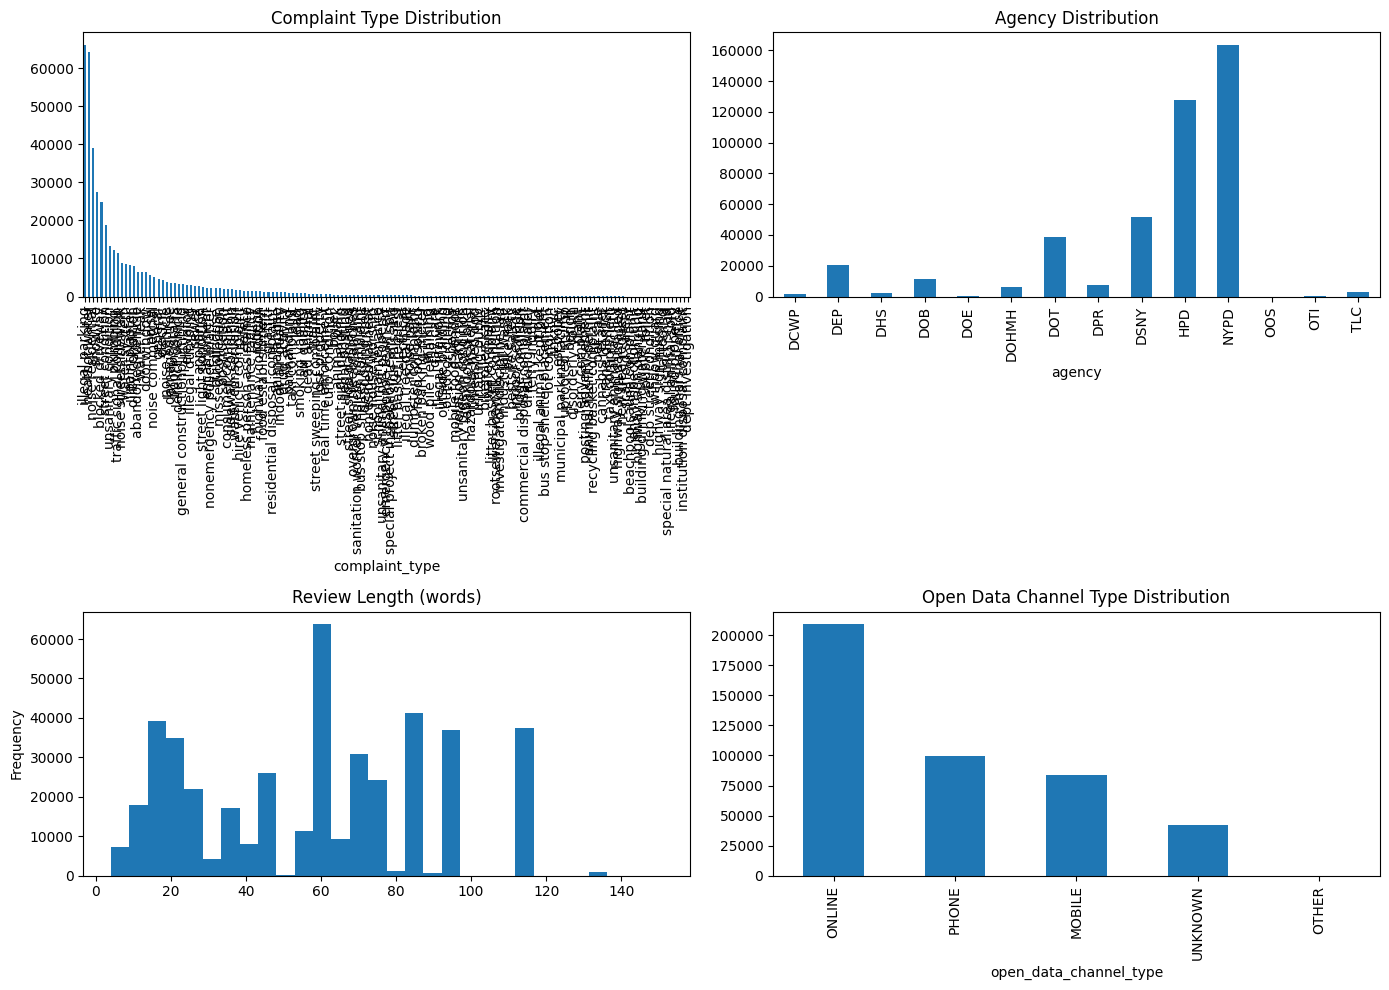

complaint_type distribution:
complaint_type
illegal parking                   66159
heathot water                     64362
noise residential                 38931
snow ice                          27453
blocked driveway                  24920
                                  ...  
illegal animal sold                   2
found property                        1
building marshal office               1
institution disposal complaint        1
dept investigation                    1
Name: count, Length: 149, dtype: int64

Average review length: 57.4 words


In [7]:
# Explore the dataset

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Complaint Type distribution
df_311['complaint_type'].value_counts().plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('Complaint Type Distribution')

# Star rating distribution
df_311['agency'].value_counts().sort_index().plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Agency Distribution')

# Review length (words per review)
df_311['resolution_description'].str.split().str.len().plot(kind='hist', bins=30, ax=axes[1,0])
axes[1,0].set_title('Review Length (words)')

# Product category distribution
df_311['open_data_channel_type'].value_counts().plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Open Data Channel Type Distribution')

plt.tight_layout()
plt.show()

# Print summary stats
print(f'complaint_type distribution:\n{df_311["complaint_type"].value_counts()}\n')
print(f'Average review length: {df_311["resolution_description"].str.split().str.len().mean():.1f} words')

In [8]:
# For your 311 project (Top 24 complaints):
resolution_results = get_top_words_by_category(df_311, 'complaint_type',  'resolution_description', top_n=24)

Cleaning text in column: resolution_description...

=== HEATHOT WATER (top 24 words) ===
  complaint            169862
  condition            128656
  hpd                  87332
  may                  82357
  tenant               61489
  apartment            53919
  still                53140
  exists               53135
  contact              51922
  inspection           51813
  original             45998
  conduct              42563
  access               35964
  attempt              34572
  correction           30570
  closed               29921
  hpdonline            29796
  verify               29049
  open                 28788
  already              28783
  building             28013
  heat                 25235
  hot                  24991
  water                24991

=== PLUMBING (top 24 words) ===
  hpd                  26949
  condition            25258
  complaint            17748
  inspection           12547
  tenant               12411
  may                  12330
  owne

In [9]:
get_sequence_stats(df_311, 'resolution_description')

Average Length: 57.40
95th Percentile: 113.00


0          85
1          27
2         113
3          64
4          71
         ... 
434717     96
434718     14
434719     53
434720    113
434721    113
Name: resolution_description, Length: 434722, dtype: int64

In [10]:
save_processed_data(df_311, "processed_311_complaints.csv")

Existing file processed_311_complaints.csv dropped.
Saved fresh processed data to /Users/mysticbluetopaz/final-capstone-e2ws-ai-topia-consulting/data/processed/processed_311_complaints.csv
